##### 常數

In [1]:
NAME = "score_13"
VIDEO = f"../../../../resources/video/20240717/2/{NAME}.mp4"  # 影片路徑

MODEL = "./models/BlazePose/pose_landmarker_full.task"  # 模型路徑

VIDEO_OUT_PATH = f"./output_video/{NAME}.mp4"  # 影片輸出路徑
PLOT_OUT_PATH = f"./output_plot/{NAME}/{NAME}"  # 表格輸出路徑

#### 套件

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
import math
import cv2

from mediapipe.tasks.python.core.base_options import BaseOptions
from mediapipe.tasks.python.vision.core.vision_task_running_mode import (
    VisionTaskRunningMode,
)
from mediapipe.tasks.python.vision.pose_landmarker import (
    PoseLandmarker,
    PoseLandmarkerOptions,
)

In [3]:
from mpl_toolkits.mplot3d.axes3d import Axes, Axes3D
from mediapipe.tasks.python.vision.pose_landmarker import PoseLandmarkerResult

In [4]:
from src.mp_lib.base import (
    PoseResult,
    ResultAnalyzer,
    LhcPoseListAnalyzer,
)
from src.draw_template import (
    draw_kpt_position_in_img,
    get_bones_plot_axes,
    get_axes_with_staggered_lines,
    get_axes_with_staggered_vector,
    get_axes_with_both_wrists_to_gravity,
    get_axes_with_both_shoulders,
    get_axes_with_shoulder_hight_diff,
)
from src.utils.plot_painter import (
    set_data_range,
    set_plot_labels,
    plot_to_opencv_img,
    draw_bool_list_line_chart,
    draw_pose_result_line_chart,
)
from src.server_api import get_video_json_result

#### 預先運行

##### 忽略警告

In [5]:
import warnings

warnings.filterwarnings("ignore")

##### 建立資料夾

In [6]:
required_paths = [f"./output/{NAME}", "./output_video/", f"./output_plot/{NAME}"]

for pth in required_paths:
    tmp_pth = Path(pth)
    if not tmp_pth.exists():
        tmp_pth.mkdir(parents=True)

##### 參數設定

In [7]:
# 模型設定
options = PoseLandmarkerOptions(
    base_options=BaseOptions(MODEL), running_mode=VisionTaskRunningMode.VIDEO
)

# 輸出路徑
video_out_path = Path(VIDEO_OUT_PATH)
plot_out_path = Path(PLOT_OUT_PATH)

is_3d = True  # 使用 3D 模型

# 影片輸出
zoom_ratio = 0.3  # 影片縮放倍率
fourcc = cv2.VideoWriter.fourcc(*"h264")  # fourcc 碼
fps = 30  # 幀率

#### 函式

##### 設定圖表座標資訊

In [8]:
def set_axes_info(is_3d: bool, ax: Axes | Axes3D) -> Axes | Axes3D:
    """設定圖表座標資訊

    Args:
        is_3d (bool): 是否為 3D 姿勢
        ax (Axes | Axes3D): 圖表座標

    Returns:
        Axes | Axes3D: 圖表座標
    """

    # 設定圖表座標資訊
    if not is_3d:
        set_plot_labels("x", "y", ax=ax)  # 設定標籤
        set_data_range([0, 1], [1, 0], ax=ax)  # 設定資料範圍
    else:
        set_plot_labels("x", "z", "y", ax)  # 設定標籤
        set_data_range([-1, 1], [-1, 1], [1, -1], ax)  # 設定資料範圍

    return ax

##### 繪製分析結果圖表

In [9]:
def draw_result_plot(
    result: PoseLandmarkerResult,
    figsize: tuple[float, float] = (6.4, 4.8),
    is_3d: bool = False,
) -> cv2.typing.MatLike:
    """繪製分析結果圖表

    Args:
        result (PoseLandmarkerResult): 姿勢結果
        figsize (tuple[float, float], optional): 圖表大小. Defaults to (6.4, 4.8).
        is_3d (bool, optional): 是否為 3D 姿勢. Defaults to False.

    Returns:
        cv2.typing.MatLike: 分析結果圖片
    """

    # 建立分析器
    analyzer = ResultAnalyzer(PoseResult(result))

    # 建立圖表
    fig = plt.figure(figsize=figsize)
    if not is_3d:
        ax: Axes = fig.add_subplot()
    else:
        ax: Axes3D = fig.add_subplot(projection="3d")
        ax.view_init(30, -90, 0)

    # 繪製表格
    if len(result.pose_world_landmarks) > 0:
        # # 純畫關鍵點
        # set_axes_info(is_3d, ax)
        # get_bones_plot_axes(result, is_3d=is_3d, ax=ax)

        #         # 姿勢評級+關節角度
        #         plot_txt = f"""Angles:
        # right shoulder: {analyzer.get_joint_angle_by_name("right_shoulder", True):.2f}
        # left shoulder: {analyzer.get_joint_angle_by_name("left_shoulder", True):.2f}
        # right waist: {analyzer.get_joint_angle_by_name("right_hip", True):.2f}
        # left waist: {analyzer.get_joint_angle_by_name("left_hip", True):.2f}
        # right knee: {analyzer.get_joint_angle_by_name("right_knee", True):.2f}
        # left knee: {analyzer.get_joint_angle_by_name("left_knee", True):.2f}"""
        #         ax.set_title(analyzer.get_lhc_label(is_3d), fontsize=40)
        #         ax.text(-2, 0, 0, plot_txt)
        #         ax.set_title(analyzer.get_lhc_label(is_3d), fontsize=40)
        #         set_axes_info(is_3d, ax)
        #         get_bones_plot_axes(result, is_3d=is_3d, ax=ax)

        # # 軀幹扭轉
        # ax: Axes = fig.add_subplot()
        # set_plot_labels("x", "z", ax=ax)  # 設定標籤
        # set_data_range([-0.3, 0.3], [-0.4, 0.2], ax=ax)  # 設定資料範圍
        # ax.set_title(
        #     f"Twist angle: {analyzer.get_pose_shoulder_hip_staggered_angle_xz():.2f}",
        #     fontsize=25,
        # )
        # get_axes_with_staggered_lines(result, False, ax)

        # # 軀幹扭轉向量交錯
        # ax: Axes = fig.add_subplot()
        # set_plot_labels("x", "z", ax=ax)  # 設定標籤
        # set_data_range([-0.01, 0.01], [-0.01, 0.01], ax=ax)  # 設定資料範圍
        # ax.set_title(
        #     f"Twist angle: {analyzer.get_pose_shoulder_hip_staggered_angle_xz():.2f}",
        #     fontsize=25,
        # )
        # ax.set_xticks([])
        # ax.set_yticks([])
        # get_axes_with_staggered_vector(result, False, ax)

        # 軀幹側傾
        shoulder_l = analyzer.pose_result.get_kpt_pos_by_name("left_shoulder", True)
        shoulder_r = analyzer.pose_result.get_kpt_pos_by_name("right_shoulder", True)
        shoudler_diff = np.linalg.norm(shoulder_l[1] - shoulder_r[1])

        ax: Axes = fig.add_subplot()
        set_data_range([-0.5, 0.5], [0.5, -0.5], ax=ax)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_title(
            f"""Shoulder y-axis position
Left: {shoulder_l[1]:.2f}, Right: {shoulder_r[1]:.2f}
Distance: {shoudler_diff:.2f}"""
        )
        get_axes_with_both_shoulders(result, ax)

        # # 軀幹側傾(棄用)
        # set_data_range([-0.55, 0.55], [-0.55, 0.55], [0.55, -0.55], ax=ax)
        # ax.set_title(
        #     f"Lateral inclination angle: {analyzer.get_pose_shoulder_hip_staggered_angle(True):.2f}",
        #     fontsize=20,
        # )
        # get_axes_with_staggered_lines(result, True, ax)

        # # 軀幹側傾向量交錯(棄用)
        # set_data_range([-0.01, 0.01], [-0.01, 0.01], [0.01, -0.01], ax=ax)
        # ax.set_title(
        #     f"Lateral inclination angle: {analyzer.get_pose_shoulder_hip_staggered_angle(True):.2f}",
        #     fontsize=25,
        # )
        # ax.set_xticklabels([])
        # ax.set_yticklabels([])
        # ax.set_zticklabels([])
        # get_axes_with_staggered_vector(result, True, ax)

        #         # 測試軀幹扭轉側傾角度
        #         set_data_range([-0.55, 0.55], [-0.55, 0.55], [0.55, -0.55], ax=ax)
        #         ax.set_title(
        #             f"""Angle(3d): {analyzer.get_pose_shoulder_hip_staggered_angle(True):.2f}
        # Angle(xz): {analyzer.get_pose_shoulder_hip_staggered_angle_xz():.2f}
        # Angle(xy): {analyzer.get_pose_shoulder_hip_staggered_angle_xy():.2f}
        # Angle(yz): {analyzer.get_pose_shoulder_hip_staggered_angle_yz():.2f}"""
        #         )
        #         get_axes_with_staggered_lines(result, True, ax)

        #         # 重心或手遠離身體
        #         gravity = [0, 0]
        #         wrist_l = analyzer.pose_result.get_kpt_pos_by_name("left_wrist", True)[0::2]
        #         wrist_r = analyzer.pose_result.get_kpt_pos_by_name("right_wrist", True)[0::2]

        #         # 計算距離
        #         wrist_to_gravity_l = np.linalg.norm(np.array(wrist_l) - np.array(gravity))
        #         wrist_to_gravity_r = np.linalg.norm(np.array(wrist_r) - np.array(gravity))

        #         ax: Axes = fig.add_subplot()
        #         set_plot_labels("x", "z", ax=ax)  # 設定標籤
        #         set_data_range([-0.7, 0.25], [-0.7, 0.5], ax=ax)  # 設定資料範圍
        #         title = f"""{analyzer.check_if_hands_at_a_distance()}
        # Left wrist to gravity: {wrist_to_gravity_l:.2f}
        # Right wrist to gravity: {wrist_to_gravity_r:.2f}"""

        #         ax.set_title(title)
        #         get_axes_with_both_wrists_to_gravity(result, ax)

        #         # 手臂抬舉且手位於手肘與肩膀之間
        #         left_shoulder_angle = analyzer.get_joint_angle_by_name("left_shoulder", True)
        #         right_shoulder_anlge = analyzer.get_joint_angle_by_name("right_shoulder", True)
        #         title = f"""{analyzer.check_if_arms_raised(True)},
        # shoulder angle:
        # left: {left_shoulder_angle:.2f}, right: {right_shoulder_anlge:.2f}"""
        #         ax.set_title(title)
        #         set_axes_info(is_3d, ax)
        #         get_bones_plot_axes(result, is_3d=is_3d, ax=ax)

        # # 手會高過肩膀
        # shoulder_l = analyzer.pose_result.get_kpt_pos_by_name("left_shoulder", True)
        # shoulder_r = analyzer.pose_result.get_kpt_pos_by_name("right_shoulder", True)
        # wrist_l = analyzer.pose_result.get_kpt_pos_by_name("left_wrist", True)
        # wrist_r = analyzer.pose_result.get_kpt_pos_by_name("right_wrist", True)
        # title = (
        #     "y-axis position\n"
        #     + f"Left shoulder: {shoulder_l[1]:.2f}, "
        #     + f"Right shoulder: {shoulder_r[1]:.2f}\n"
        #     + f"Left wrist: {wrist_l[1]:.2f}, "
        #     + f"Right wrist: {wrist_r[1]:.2f}"
        # )
        # ax.set_title(title)
        # set_axes_info(is_3d, ax)
        # get_bones_plot_axes(result, is_3d=is_3d, ax=ax)

        # # 計算人體身高
        # eye_l = analyzer.pose_result.get_kpt_pos_by_name("left_eye", True)
        # eye_r = analyzer.pose_result.get_kpt_pos_by_name("right_eye", True)
        # heel_l = analyzer.pose_result.get_kpt_pos_by_name("left_heel", True)
        # heel_r = analyzer.pose_result.get_kpt_pos_by_name("right_heel", True)

        # eye_center = np.mean([eye_l, eye_r], axis=0)
        # heel_center = np.mean([heel_l, heel_r], axis=0)
        # height = np.linalg.norm(eye_center[1] - heel_center[1])

        # plot_txt = f"length: {height:.2f}"
        # ax.set_title(plot_txt, fontsize=30)
        # set_axes_info(is_3d, ax)
        # get_bones_plot_axes(result, is_3d=is_3d, ax=ax)
        # ax.scatter3D(eye_center[0], eye_center[2], eye_center[1], c="#f0f")
        # ax.scatter3D(heel_center[0], heel_center[2], heel_center[1], c="#f0f")

        ax.legend()
    else:
        ax.set_title("NO DATA")

    # 將圖表轉換成圖片格式
    rgb = cv2.cvtColor(plot_to_opencv_img(fig), cv2.COLOR_RGBA2BGR)

    plt.close(fig)  # 關閉圖表

    return rgb

#### 開始測試

##### 計算影像資料

In [10]:
cap = cv2.VideoCapture(VIDEO)  # 取得串流資訊
lhc_analyzer = LhcPoseListAnalyzer()  # LHC 姿勢分析物件

# 影片大小
cap_size = np.array(
    [
        int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
    ]
)
### 縮放原始影片大小
cap_size = (cap_size * zoom_ratio).astype(np.uint)
# 表格大小
plot_size = np.array([cap_size[0] * 2, cap_size[1]])
# 影片輸出寬高
out_width = cap_size[0] + plot_size[0]
out_height = cap_size[1]

# 建立模型物件
landmarker = PoseLandmarker.create_from_options(options)

# 影片輸出物件
video_out = cv2.VideoWriter(str(video_out_path), fourcc, fps, (out_width, out_height))

# 預設輸出影像幀
default_frame = np.zeros((out_height, out_width, 3))

# 進行串流
i = 0
while cap.isOpened():
    # 抓取影像
    ret, frame = cap.read()
    if not ret:
        cv2.destroyAllWindows()
        print("Can't receive frame (stream end?). Exiting ...")
        break

    # 取得並儲存影像分析結果
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)
    result = landmarker.detect_for_video(mp_img, int(cap.get(cv2.CAP_PROP_POS_MSEC)))

    # 如果成功在圖片中取得人體姿勢，則加入結果到 lhc_analyzer 中
    if len(result.pose_landmarks) > 0:
        lhc_analyzer += [result]

    ### 縮放原始影片大小
    resized_frame = cv2.resize(frame, cap_size)

    ### 繪製分析結果
    mp_img = draw_kpt_position_in_img(result, resized_frame)  # 2D 關鍵點
    # mp_img = draw_debug_in_img(result, mp_img, is_3d)  # 偵錯資訊
    plot_img = draw_result_plot(result, plot_size / 100, is_3d)  # 分析圖表
    # 組合原始圖片和分析圖表
    out_frame = np.concatenate((plot_img, mp_img), axis=1)

    if i % 21 == 0:
        cv2.imwrite(f"./output/{NAME}/plot_img_{i}.png", plot_img)
        cv2.imwrite(f"./output/{NAME}/frame_{i}.png", frame)

    i += 1

    # 儲存影片幀
    video_out.write(out_frame)

    # 顯示 OpenCV 視窗畫面
    cv2.imshow("debug", out_frame)

    if cv2.waitKey(1) == ord("q"):
        cv2.destroyAllWindows()
        break


cap.release()
video_out.release()
landmarker.close()
print("finish")

Can't receive frame (stream end?). Exiting ...
finish


##### 顯示關鍵點座標

In [11]:
# 顯示關鍵點座標
from src.mp_lib import value

landmarks = lhc_analyzer[2].pose_world_landmarks[0]
kpt_list = value.KPT_LIST.copy()

for kpt_name, landmark in zip(kpt_list, landmarks):
    print(f"{kpt_name}\t{landmark.x}\t{landmark.y}\t{landmark.z}")

nose	-0.08211059123277664	-0.63251793384552	0.020439382642507553
left_eye_inner	-0.08237561583518982	-0.6590017676353455	-0.0024299737997353077
left_eye	-0.08215517550706863	-0.6595525741577148	-0.0018002130091190338
left_eye_outer	-0.08251211792230606	-0.659577488899231	-0.0019599879160523415
right_eye_inner	-0.0658993050456047	-0.6597423553466797	0.02331939898431301
right_eye	-0.06539079546928406	-0.6606681942939758	0.022668465971946716
right_eye_outer	-0.06576446443796158	-0.6620287895202637	0.02325914055109024
left_ear	-0.0348493792116642	-0.6222299933433533	-0.07485142350196838
right_ear	0.021782711148262024	-0.6319018602371216	0.03009023517370224
mouth_left	-0.060970328748226166	-0.6017219424247742	-0.002727682003751397
mouth_right	-0.04573732987046242	-0.6031016707420349	0.027066487818956375
left_shoulder	-0.023741545155644417	-0.5034717917442322	-0.17513951659202576
right_shoulder	0.09035133570432663	-0.5457322597503662	0.09914751350879669
left_elbow	-0.23337125778198242	-0.674

##### 測試分析結果

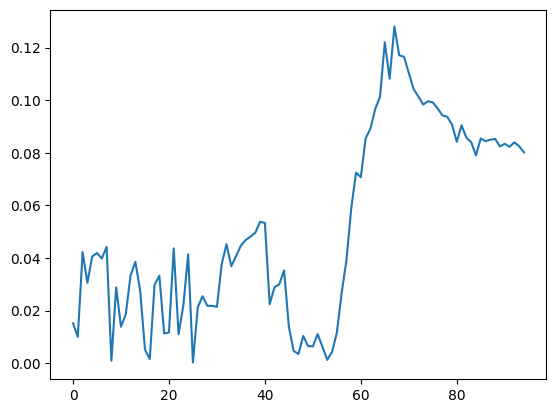

In [12]:
# 分析肩膀差距變化
fig = plt.figure()
ax: Axes = fig.add_subplot()
get_axes_with_shoulder_hight_diff(lhc_analyzer.result_lst, ax)
fig.show()

##### 顯示分析結果

In [13]:
results = get_video_json_result(VIDEO)
for key, val in results.items():
    print(key, val, sep="  \t")

Can't receive frame (stream end?). Exiting ...
extra scores: [3. 3. 0. 2.]
sum of extra scores: 6.0
extra scores: [3. 3. 0. 2.]
sum of extra scores: 6.0
start  	A2
end  	A5
extra 1  	FREQUENTLY_OR_CONSTANTLY
extra 2  	FREQUENTLY_OR_CONSTANTLY
extra 3  	RARELY
extra 4  	FREQUENTLY_OR_CONSTANTLY
pose score  	13
extra score  	6.0
total score  	19.0


##### 顯示姿勢折線圖

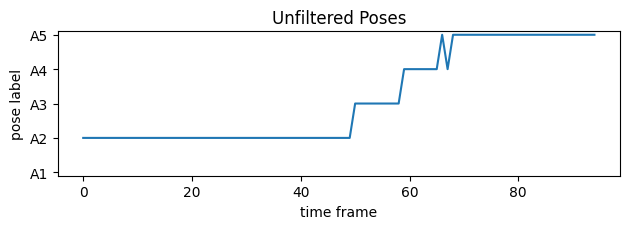

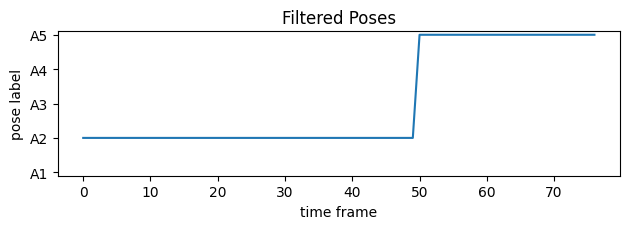

In [14]:
# 未過濾姿勢
fig = plt.figure(figsize=(6.4, 2.4))
ax = fig.add_subplot()
ax.set_title("Unfiltered Poses")

unfiltered = lhc_analyzer.get_lhc_label_list(is_3d)
draw_pose_result_line_chart(unfiltered, "unfiltered", ax)

fig.tight_layout()
fig.savefig(f"{str(plot_out_path)}_pose.png")
fig.show()

# 已過濾姿勢
fig = plt.figure(figsize=(6.4, 2.4))
ax = fig.add_subplot()
ax.set_title("Filtered Poses")

filtered = LhcPoseListAnalyzer.filter_label_list_in_fun_e(unfiltered)
draw_pose_result_line_chart(filtered, "filtered", ax)

fig.tight_layout()
fig.savefig(f"{str(plot_out_path)}_filtered.png")
fig.show()

##### 顯示額外加分折線圖

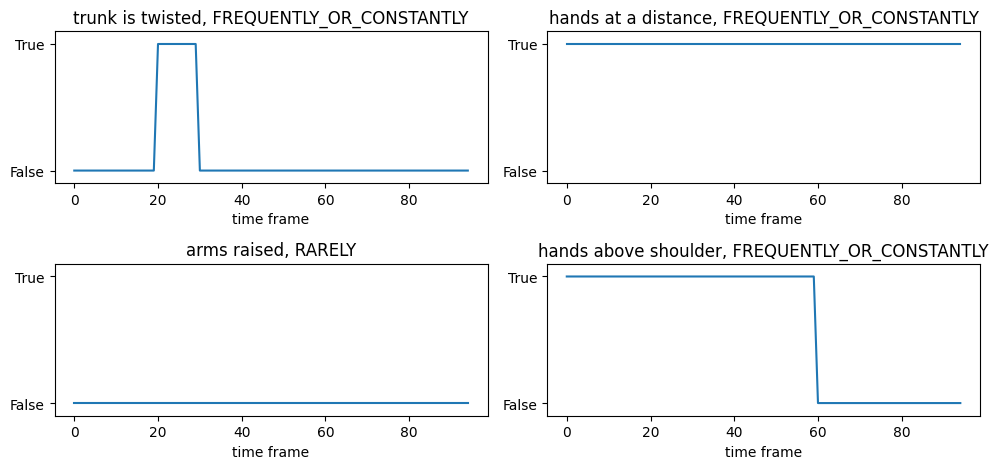

In [15]:
fig = plt.figure(figsize=(10, 4.8))

ax0 = fig.add_subplot(221)
ax0.set_title(
    f"trunk is twisted, {lhc_analyzer.get_frequency_of_trunk_is_twisted(is_3d).name}"
)
draw_bool_list_line_chart(lhc_analyzer.get_trunk_is_twisted_list(is_3d), "result", ax0)

ax1 = fig.add_subplot(222)
ax1.set_title(
    f"hands at a distance, {lhc_analyzer.get_frequency_of_hands_at_a_distance(is_3d).name}"
)
draw_bool_list_line_chart(
    lhc_analyzer.get_hands_at_a_distance_list(is_3d), "result", ax1
)

ax2 = fig.add_subplot(223)
ax2.set_title(f"arms raised, {lhc_analyzer.get_frequency_of_arms_raised(is_3d).name}")
draw_bool_list_line_chart(lhc_analyzer.get_arms_raised_list(is_3d), "result", ax2)

ax3 = fig.add_subplot(224)
ax3.set_title(
    f"hands above shoulder, {lhc_analyzer.get_frequency_of_hands_above_shoulder(is_3d).name}"
)
draw_bool_list_line_chart(
    lhc_analyzer.get_hands_above_shoulder_list(is_3d), "result", ax3
)

fig.tight_layout()
fig.savefig(f"{str(plot_out_path)}_extra.png")
fig.show()

##### 分別顯示額外加分折線圖

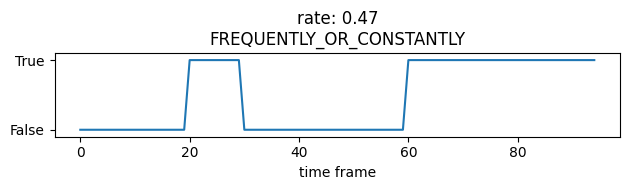

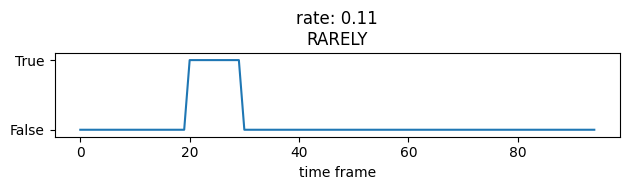

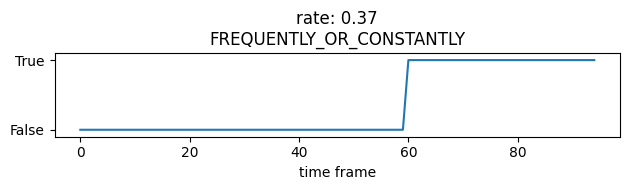

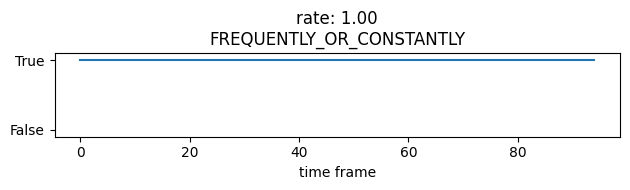

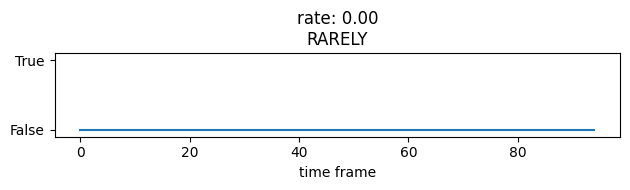

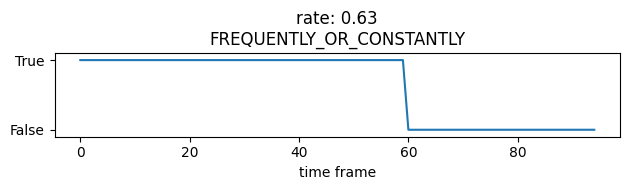

In [16]:
title = ""
bool_lst = []
fig_size = (6.4, 2)

# extra 1
bool_lst = lhc_analyzer.get_trunk_is_twisted_or_lateral_inclination_list(is_3d)
rate = bool_lst.count(True) / len(bool_lst)
title = (
    f"rate: {rate:.2f}\n{lhc_analyzer.get_frequency_of_trunk_is_twisted(is_3d).name}"
)

fig = plt.figure(figsize=fig_size)
ax = fig.add_subplot()
ax.set_title(title)
draw_bool_list_line_chart(bool_lst, "result", ax)
fig.tight_layout()
fig.savefig(f"{str(plot_out_path)}_extra1.png")
fig.show()

# extra 1(軀幹扭轉)
bool_lst = lhc_analyzer.get_trunk_is_twisted_list(is_3d)
rate = bool_lst.count(True) / len(bool_lst)
title = f"rate: {rate:.2f}\n{LhcPoseListAnalyzer.get_frequency_from_bool_list(bool_lst).name}"

fig = plt.figure(figsize=fig_size)
ax = fig.add_subplot()
ax.set_title(title)
draw_bool_list_line_chart(bool_lst, "result", ax)
fig.tight_layout()
fig.savefig(f"{str(plot_out_path)}_extra1(扭轉).png")
fig.show()

# extra 1(側傾)
bool_lst = lhc_analyzer.get_trunk_is_lateral_inclination_list(is_3d)
rate = bool_lst.count(True) / len(bool_lst)
title = f"rate: {rate:.2f}\n{LhcPoseListAnalyzer.get_frequency_from_bool_list(bool_lst).name}"

fig = plt.figure(figsize=fig_size)
ax = fig.add_subplot()
ax.set_title(title)
draw_bool_list_line_chart(bool_lst, "result", ax)
fig.tight_layout()
fig.savefig(f"{str(plot_out_path)}_extra1(側傾).png")
fig.show()

# extra 2
bool_lst = lhc_analyzer.get_hands_at_a_distance_list(is_3d)
rate = bool_lst.count(True) / len(bool_lst)
title = (
    f"rate: {rate:.2f}\n{lhc_analyzer.get_frequency_of_hands_at_a_distance(is_3d).name}"
)

fig = plt.figure(figsize=fig_size)
ax = fig.add_subplot()
ax.set_title(title)
draw_bool_list_line_chart(bool_lst, "result", ax)
fig.tight_layout()
fig.savefig(f"{str(plot_out_path)}_extra2.png")
fig.show()

# extra 3
bool_lst = lhc_analyzer.get_arms_raised_list(is_3d)
rate = bool_lst.count(True) / len(bool_lst)
title = f"rate: {rate:.2f}\n{lhc_analyzer.get_frequency_of_arms_raised(is_3d).name}"

fig = plt.figure(figsize=fig_size)
ax = fig.add_subplot()
ax.set_title(title)
draw_bool_list_line_chart(bool_lst, "result", ax)
fig.tight_layout()
fig.savefig(f"{str(plot_out_path)}_extra3.png")
fig.show()

# extra 4
bool_lst = lhc_analyzer.get_hands_above_shoulder_list(is_3d)
rate = bool_lst.count(True) / len(bool_lst)
title = f"rate: {rate:.2f}\n{lhc_analyzer.get_frequency_of_hands_above_shoulder(is_3d).name}"

fig = plt.figure(figsize=fig_size)
ax = fig.add_subplot()
ax.set_title(title)
draw_bool_list_line_chart(bool_lst, "result", ax)
fig.tight_layout()
fig.savefig(f"{str(plot_out_path)}_extra4.png")
fig.show()

##### (測試)顯示額外加分折線圖

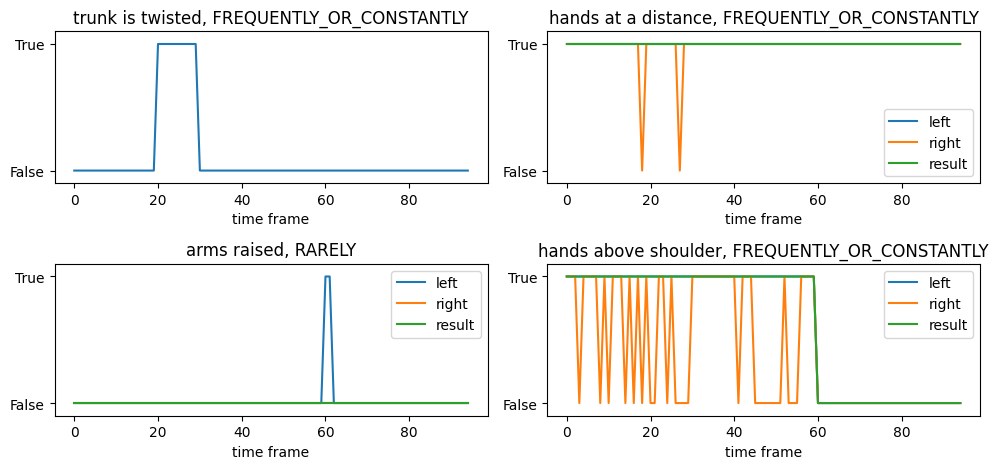

In [17]:
fig = plt.figure(figsize=(10, 4.8))

ax0 = fig.add_subplot(221)
ax0.set_title(
    f"trunk is twisted, {lhc_analyzer.get_frequency_of_trunk_is_twisted(is_3d).name}"
)
draw_bool_list_line_chart(lhc_analyzer.get_trunk_is_twisted_list(is_3d), "result", ax0)

ax1 = fig.add_subplot(222)
ax1.set_title(
    f"hands at a distance, {lhc_analyzer.get_frequency_of_hands_at_a_distance(is_3d).name}"
)
draw_bool_list_line_chart(
    lhc_analyzer.get_hands_at_a_distance_list_by_one_side(True, is_3d), "left", ax1
)
draw_bool_list_line_chart(
    lhc_analyzer.get_hands_at_a_distance_list_by_one_side(False, is_3d), "right", ax1
)
draw_bool_list_line_chart(
    lhc_analyzer.get_hands_at_a_distance_list(is_3d), "result", ax1
)
ax1.legend()

ax2 = fig.add_subplot(223)
ax2.set_title(f"arms raised, {lhc_analyzer.get_frequency_of_arms_raised(is_3d).name}")
draw_bool_list_line_chart(
    lhc_analyzer.get_arms_raised_list_by_one_side(True, is_3d), "left", ax2
)
draw_bool_list_line_chart(
    lhc_analyzer.get_arms_raised_list_by_one_side(False, is_3d), "right", ax2
)
draw_bool_list_line_chart(lhc_analyzer.get_arms_raised_list(is_3d), "result", ax2)
ax2.legend()

ax3 = fig.add_subplot(224)
ax3.set_title(
    f"hands above shoulder, {lhc_analyzer.get_frequency_of_hands_above_shoulder(is_3d).name}"
)
draw_bool_list_line_chart(
    lhc_analyzer.get_hands_above_shoulder_list_by_one_side(True, is_3d), "left", ax3
)
draw_bool_list_line_chart(
    lhc_analyzer.get_hands_above_shoulder_list_by_one_side(False, is_3d), "right", ax3
)
draw_bool_list_line_chart(
    lhc_analyzer.get_hands_above_shoulder_list(is_3d), "result", ax3
)
ax3.legend()

fig.tight_layout()
fig.show()